In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

This is a nptebook of an assignment I did for my data mining class using Apriori Association Rules and Bayesian Network. Apriori is an algorithm for frequent item set mining and association rule learning over dataset. It proceeds by identifying the frequent individual items in a dataset and extending them to larger and larger item sets as long as those item sets appear sufficiently often in the dataset. Bayesian Network instead focus on the Conditional Dependencies probability between each values in a dataset. I did my work using securities of the stock exchange

In [2]:
from pandas_datareader import data
import matplotlib.pyplot as plt
import pandas as pd

Required libraries

In [4]:
!pip install yfinance

In [5]:
!pip install -U bnlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 382.5 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 4.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 16.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.0 MB/s eta 0:00:00a 0:00:01
  Preparing

In [6]:
import yfinance as yf

# Set the start and end date
start_date = '2016-01-01'
end_date = '2022-07-31'

# Set the ticker
tickers = ['AMZN', 'BRK-B', 'DELL', 'BA', 'LMT', 'MCK', 'GM', 'NFLX', 'SQ', 'EXPE', 'F', 'INTC', 'CSCO', 'BRK-A', 'GOOG', 'GOOGL', 'AAPL', 'MSFT', 'JPM', 'TSLA', 'AMD', 'NVDA', 'RIVN', 'META', 'JNJ', 'V', 'WMT', 'PG', 'XOM', 'MA', 'HD', 'PFE', 'KO', 'CVX','BAC', 'COST', 'VZ', 'ORCL', 'MRO', 'GME', 'MRNA', 'CRM', 'UPS', 'WFC', 'T', 'RTX', 'PM', 'MS', 'AMGN', 'IBM', 'CVS', 'SCHW', 'LOW', 'AMT', 'NKE', 'DIS', 'TMUS', 'DHR', 'ABT', 'MCD', 'TGT', 'ASAN', 'UBER', 'ABNB']

# Get the data
df = yf.download("SPY", start_date, end_date, interval = "1wk")
df = df.reset_index(level=0)
df['Ticker']='SPY'
for i in tickers:
  df2 = yf.download(i, start_date, end_date, interval = "1wk")
  df2 = df2.reset_index(level=0)
  df2['Ticker']=i
  frames = [df, df2]
  df = pd.concat(frames)
df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2016-01-01,200.490005,201.899994,193.589996,194.050003,172.583740,6.987480e+08,SPY
1,2016-01-08,195.190002,195.850006,187.660004,191.929993,170.698227,1.032054e+09,SPY
2,2016-01-15,186.770004,190.110001,181.020004,186.690002,166.037903,1.002412e+09,SPY
3,2016-01-22,189.779999,191.559998,187.059998,189.110001,168.190231,7.692086e+08,SPY
4,2016-01-29,190.020004,194.580002,187.100006,191.600006,170.404739,8.737425e+08,SPY
...,...,...,...,...,...,...,...,...
81,2022-06-27,103.959999,105.449997,86.709999,91.410004,91.410004,3.661880e+07,ABNB
82,2022-07-04,88.879997,98.120003,86.750000,97.349998,97.349998,2.649830e+07,ABNB
83,2022-07-11,96.000000,97.685997,90.169998,94.660004,94.660004,3.300830e+07,ABNB
84,2022-07-18,96.779999,110.099998,95.980003,103.970001,103.970001,2.813160e+07,ABNB


In [7]:
df=df.dropna()
df2=df.copy()
df2=df2.set_index('Ticker')
df2['WeeklyReturns']=((df2['Close']-df2.groupby(level='Ticker').Close.shift(1))/df2.groupby(level='Ticker').Close.shift(1))*100
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21187 entries, SPY to ABNB
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           21187 non-null  datetime64[ns]
 1   Open           21187 non-null  float64       
 2   High           21187 non-null  float64       
 3   Low            21187 non-null  float64       
 4   Close          21187 non-null  float64       
 5   Adj Close      21187 non-null  float64       
 6   Volume         21187 non-null  float64       
 7   WeeklyReturns  21122 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 1.5+ MB


In [8]:
df['WeeklyReturns']=df2['WeeklyReturns'].values
df=df.fillna(0)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [9]:
import plotly.express as px

fig=px.histogram(df, x='Ticker', y='WeeklyReturns')
fig.show()

  Function Use to encode the data into binary, such that all the positive change will be a 1

In [11]:
def hot_encode(x):
    if(x<= 0):
        return 0
    if(x> 0):
        return 1

Encoding the data

In [12]:
basket = pd.pivot_table(data=df,index='Date',columns='Ticker',values='WeeklyReturns', aggfunc='sum',fill_value=0)
basket_sets = basket.applymap(hot_encode)
basket_sets.head()

Ticker,AAPL,ABNB,ABT,AMD,AMGN,AMT,AMZN,ASAN,BA,BAC,...,TGT,TMUS,TSLA,UBER,UPS,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-01-08,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
2016-01-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2016-01-22,0,0,0,0,0,1,1,0,0,1,...,1,1,0,0,1,0,1,1,1,1
2016-01-29,1,0,1,1,1,0,0,0,1,0,...,0,1,0,0,1,1,1,0,1,1


Using Apriori association rules to find any association between securities 

In [13]:
from mlxtend.frequent_patterns import apriori, association_rules
frequent_itemsets = apriori(basket_sets, min_support=0.2, use_colnames=True)#0.5
rules = association_rules(frequent_itemsets, metric ="lift", min_threshold = 1)
rules = rules.sort_values(['confidence', 'lift'], ascending =[False, False])
print(rules.head(15))

              antecedents consequents  antecedent support  consequent support  \
1750  (MSFT, GOOGL, AAPL)      (GOOG)            0.200000            0.311450   
1863   (MSFT, GOOGL, CRM)      (GOOG)            0.204580            0.311450   
1947   (MSFT, GOOGL, SPY)      (GOOG)            0.222901            0.311450   
1961     (MSFT, GOOGL, V)      (GOOG)            0.200000            0.311450   
1528        (MSFT, GOOGL)      (GOOG)            0.247328            0.311450   
1211         (BRK-A, JPM)     (BRK-B)            0.233588            0.293130   
904         (GOOGL, AAPL)      (GOOG)            0.225954            0.311450   
1517        (GOOGL, META)      (GOOG)            0.222901            0.311450   
1331        (GOOGL, COST)      (GOOG)            0.221374            0.311450   
1808    (BRK-A, BAC, JPM)     (BRK-B)            0.219847            0.293130   
1794   (GOOGL, SPY, AMZN)      (GOOG)            0.210687            0.311450   
881         (AAPL, BRK-B)   

/opt/conda/lib/python3.7/site-packages/mlxtend/frequent_patterns/fpcommon.py:115: DeprecationWarning:

DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type



In [18]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets[ (frequent_itemsets['length'] ==2)].sort_values(['support'], ascending =[False]).head(15)

,support,itemsets,length
320,0.300763,"(GOOGL, GOOG)",2
173,0.285496,"(BRK-A, BRK-B)",2
428,0.279389,"(V, MA)",2
453,0.265649,"(MSFT, SPY)",2
161,0.264122,"(BAC, JPM)",2
332,0.258015,"(GOOG, SPY)",2
493,0.254962,"(V, SPY)",2
423,0.253435,"(SPY, MA)",2
348,0.253435,"(GOOGL, SPY)",2
303,0.251908,"(DHR, SPY)",2


In the next step we are going to use Bayesian network to build a model based on conditional dependencies 

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn]> Set node properties.
[bnlearn]> Set edge properties.
[bnlearn] >Plot based on Bayesian model


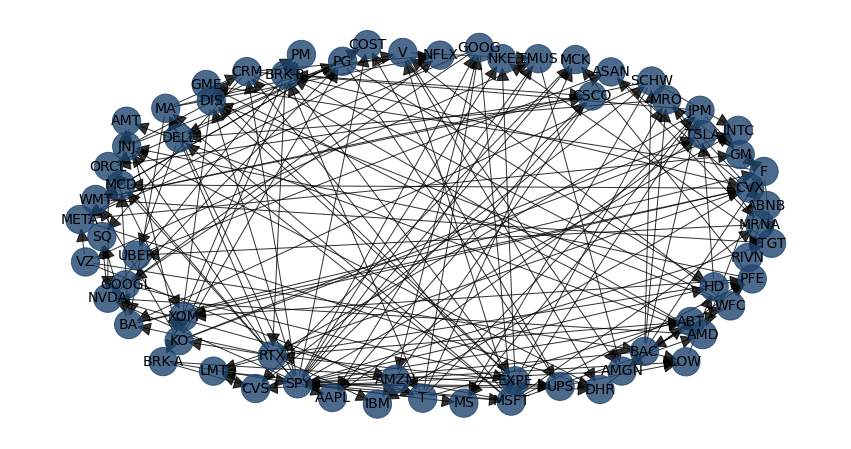

In [20]:
import bnlearn as bn
DAG = bn.structure_learning.fit(basket_sets)
G = bn.plot(DAG)

Building using Maximum Likelihood which follows the principle of occurence. The model uses relative frequencies with which the variables states have occured with. Prone to overfit

In [21]:
model_mle = bn.parameter_learning.fit(DAG, basket_sets, methodtype='maximumlikelihood')

[bnlearn] >Parameter learning> Computing parameters using [maximumlikelihood]
[bnlearn] >Conversion of adjmat to BayesianNetwork.
[bnlearn] >CPD of AAPL:
+---------+----------------------+-----+---------------------+
| CSCO    | CSCO(0)              | ... | CSCO(1)             |
+---------+----------------------+-----+---------------------+
| SPY     | SPY(0)               | ... | SPY(1)              |
+---------+----------------------+-----+---------------------+
| TMUS    | TMUS(0)              | ... | TMUS(1)             |
+---------+----------------------+-----+---------------------+
| AAPL(0) | 0.9711286089238845   | ... | 0.22429906542056074 |
+---------+----------------------+-----+---------------------+
| AAPL(1) | 0.028871391076115485 | ... | 0.7757009345794392  |
+---------+----------------------+-----+---------------------+
[bnlearn] >CPD of NVDA:
+---------+----------------------+-----+---------+---------------------+
| AAPL    | AAPL(0)              | ... | AAPL(1) | AAPL(

Bayes methodtype predictions are a lot more conservatives in assuming conditional probabilities. 

In [22]:
model_bayes = bn.parameter_learning.fit(DAG, basket_sets, methodtype='bayes')

[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Conversion of adjmat to BayesianNetwork.
[bnlearn] >CPD of AAPL:
+---------+---------------------+-----+--------------------+
| CSCO    | CSCO(0)             | ... | CSCO(1)            |
+---------+---------------------+-----+--------------------+
| SPY     | SPY(0)              | ... | SPY(1)             |
+---------+---------------------+-----+--------------------+
| TMUS    | TMUS(0)             | ... | TMUS(1)            |
+---------+---------------------+-----+--------------------+
| AAPL(0) | 0.8547430830039525  | ... | 0.3728448275862069 |
+---------+---------------------+-----+--------------------+
| AAPL(1) | 0.14525691699604742 | ... | 0.6271551724137931 |
+---------+---------------------+-----+--------------------+
[bnlearn] >CPD of NVDA:
+---------+--------------------+-----+--------------------+
| AAPL    | AAPL(0)            | ... | AAPL(1)            |
+---------+--------------------+-----+-----

Now we can do inference fit to see how securities react if another specific security increases. Let's begin with APPL and with our two model. Altough the parameter learning part already show us what securities directly have a relationship with each other, it might be useful to try with unrelated securities

But let's begin by looking at securities that are in similar areas such as AAPL and MSFT

In [23]:
q1 = bn.inference.fit(model_mle, variables=['AAPL'], evidence={'MSFT':1})
q1 = bn.inference.fit(model_bayes, variables=['AAPL'], evidence={'MSFT':1})
q1 = bn.inference.fit(model_mle, variables=['AAPL'], evidence={'TSLA':1})
q1 = bn.inference.fit(model_bayes, variables=['AAPL'], evidence={'TSLA':1})

[bnlearn] >Variable Elimination..


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

+----+--------+----------+
|    |   AAPL |        p |
+====+========+==========+
|  0 |      0 | 0.309785 |
+----+--------+----------+
|  1 |      1 | 0.690215 |
+----+--------+----------+
[bnlearn] >Variable Elimination..


  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/43 [00:00<?, ?it/s]

+----+--------+----------+
|    |   AAPL |        p |
+====+========+==========+
|  0 |      0 | 0.269263 |
+----+--------+----------+
|  1 |      1 | 0.730737 |
+----+--------+----------+
[bnlearn] >Variable Elimination..


  0%|          | 0/43 [00:00<?, ?it/s]

  0%|          | 0/43 [00:00<?, ?it/s]

+----+--------+---------+
|    |   AAPL |       p |
+====+========+=========+
|  0 |      0 | 0.44621 |
+----+--------+---------+
|  1 |      1 | 0.55379 |
+----+--------+---------+


By this result, we can see what is the probability of AAPL increasing knowing that microsoft is increasing. However, the model is telling us straight up that one security that can improve our inference precision is SPY. Let's add it 

In [24]:
q1 = bn.inference.fit(model_mle, variables=['AAPL'], evidence={'MSFT':1, 'SPY':1})
q1 = bn.inference.fit(model_bayes, variables=['AAPL'], evidence={'MSFT':1, 'SPY':1})
q1 = bn.inference.fit(model_mle, variables=['AAPL'], evidence={'TSLA':1, 'SPY':1})
q1 = bn.inference.fit(model_bayes, variables=['AAPL'], evidence={'TSLA':1, 'SPY':1})

[bnlearn] >Variable Elimination..


  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

+----+--------+----------+
|    |   AAPL |        p |
+====+========+==========+
|  0 |      0 | 0.215303 |
+----+--------+----------+
|  1 |      1 | 0.784697 |
+----+--------+----------+
[bnlearn] >Variable Elimination..


  0%|          | 0/39 [00:00<?, ?it/s]

...

  0%|          | 0/42 [00:00<?, ?it/s]

+----+--------+----------+
|    |   AAPL |        p |
+====+========+==========+
|  0 |      0 | 0.137945 |
+----+--------+----------+
|  1 |      1 | 0.862055 |
+----+--------+----------+
[bnlearn] >Variable Elimination..


  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

+----+--------+---------+
|    |   AAPL |       p |
+====+========+=========+
|  0 |      0 | 0.34288 |
+----+--------+---------+
|  1 |      1 | 0.65712 |
+----+--------+---------+


Our inferences increase a lot, especially when we consider the bayes model which is a lot more conservative than the Maximum Likelihood one. Let's focus on using Bayes approach

In [28]:
q1 = bn.inference.fit(model_bayes, variables=['AAPL'], evidence={'AMZN':1, 'TSLA':1, 'GOOG':1})

[bnlearn] >Variable Elimination..


  0%|          | 0/44 [00:00<?, ?it/s]

  0%|          | 0/44 [00:00<?, ?it/s]

+----+--------+---------+
|    |   AAPL |       p |
+====+========+=========+
|  0 |      0 | 0.40541 |
+----+--------+---------+
|  1 |      1 | 0.59459 |
+----+--------+---------+


It might be useful to check with other securities. Let's check TSLA and other car compnies GM and Ford

In [29]:
q1 = bn.inference.fit(model_bayes, variables=['TSLA'], evidence={'F':1, 'GM':1})

[bnlearn] >Variable Elimination..


  0%|          | 0/43 [00:00<?, ?it/s]

  0%|          | 0/43 [00:00<?, ?it/s]

+----+--------+---------+
|    |   TSLA |       p |
+====+========+=========+
|  0 |      0 | 0.54026 |
+----+--------+---------+
|  1 |      1 | 0.45974 |
+----+--------+---------+


TSLA doesn't associate with F and GM. Let's check if there is a change in the CPD when both decrease and let's say AAPL increase

In [31]:
q1 = bn.inference.fit(model_bayes, variables=['TSLA'], evidence={'F':0, 'GM':0, 'AAPL':1})

[bnlearn] >Variable Elimination..


  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

+----+--------+----------+
|    |   TSLA |        p |
+====+========+==========+
|  0 |      0 | 0.446813 |
+----+--------+----------+
|  1 |      1 | 0.553187 |
+----+--------+----------+


We can deduce that TSLA security associate with tech companies